# Import Libraries and Data

In [606]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

In [607]:
df = pd.read_pickle('../data/processed/ft_engineered2.pkl')

In [608]:
df.head()

,churned,loyalty_points,order_timespan_days,price,order_quantity
3897,Active,242,230,554.07,8
5628,Active,426,204,1001.93,16
1756,Inactive,125,394,649.95,48
2346,Inactive,190,379,300.25,210
2996,Inactive,385,293,1363.64,4


# Model Training

In [609]:
X = df.drop('churned', axis=1)
y = df['churned']

In [610]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rfc = RandomForestClassifier(max_depth=2, random_state = 0)
rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [612]:
y_pred = rfc.predict(X_test)

In [613]:
print(y_pred[:10])

['Active' 'Inactive' 'Inactive' 'Active' 'Active' 'Active' 'Active'
 'Active' 'Inactive' 'Active']


# Permutation Importance and Feature Importance

Feature Importance Ranking:
price: 0.3497
order_timespan_days: 0.2517
loyalty_points: 0.2019
order_quantity: 0.1967


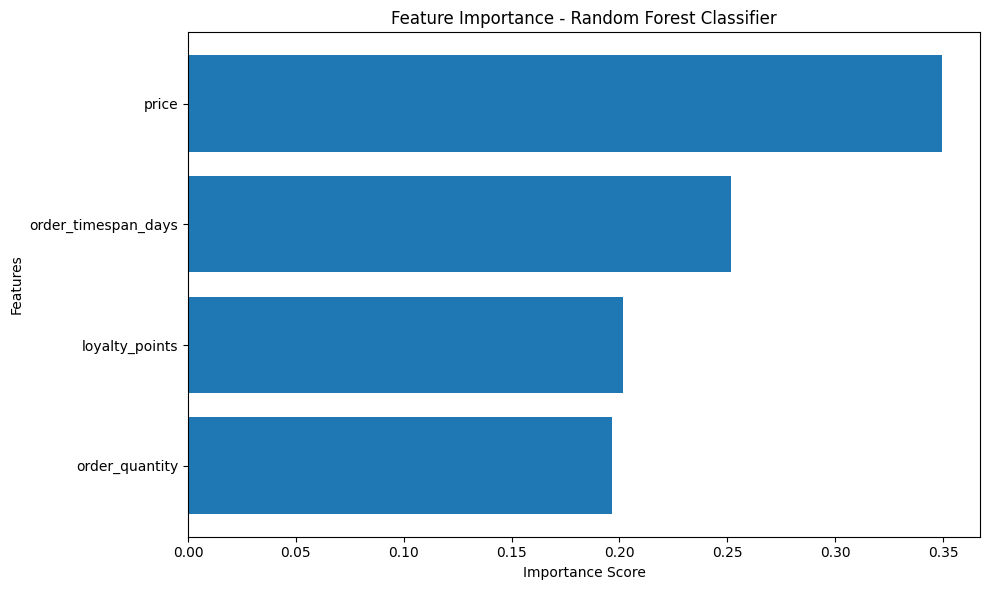

In [614]:
# Feature Importance Analysis
import pandas as pd
import matplotlib.pyplot as plt

importances = rfc.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("Feature Importance Ranking:")
for idx, row in feature_importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest Classifier')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()

In [615]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [616]:
#Check columns for basis to check index (for Permutation importance)
X_test.columns.to_list()
for i, col in enumerate(X_test):
    print(f"{str(col)}: index {i}")

loyalty_points: index 0
order_timespan_days: index 1
price: index 2
order_quantity: index 3


In [617]:
importance = permutation_importance(rfc,X_test,y_test, n_repeats=10, random_state=42, n_jobs=1)
sorted_imp = importance.importances_mean.argsort()
print(f"Permutation importance results: {sorted_imp}")

Permutation importance results: [0 2 1 3]


In [618]:
feature_names = X_test.columns
importance_scores = importance.importances_mean
 
# Sort by importance (descending)
sorted_indices = importance_scores.argsort()[::-1]  # Reverse for descending order
sorted_features = feature_names[sorted_indices]
sorted_scores = importance_scores[sorted_indices]

print("Permutation Importance (sorted):")
for feature, score in zip(sorted_features, sorted_scores):
    print(f"{feature}: {score:.4f}")

Permutation Importance (sorted):
order_quantity: 0.0112
order_timespan_days: 0.0094
price: 0.0066
loyalty_points: 0.0029


argsort() sorts indices from lowest to highest. (worst to best feature in the end)

For example the result: [6 2 0 1 4 3 5], the 5th index has the best feature.

In [619]:
# Convert churned to binary
y = y.map({'Active': 0, 'Inactive': 1})

# Model Evaluation

In [620]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

accuracy = accuracy_score(y_test, y_pred)

In [621]:
print("Random Forest Classifier Results:")
print(f"Accuracy: {accuracy:.4f}")
#p precision and s support
print(classification_report(y_test, y_pred, target_names=['p','s']))

Random Forest Classifier Results:
Accuracy: 0.5333
              precision    recall  f1-score   support

           p       0.54      0.68      0.60       500
           s       0.52      0.37      0.43       460

    accuracy                           0.53       960
   macro avg       0.53      0.53      0.52       960
weighted avg       0.53      0.53      0.52       960



In [622]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (raw counts):")
print(cm)

Confusion Matrix (raw counts):
[[340 160]
 [288 172]]


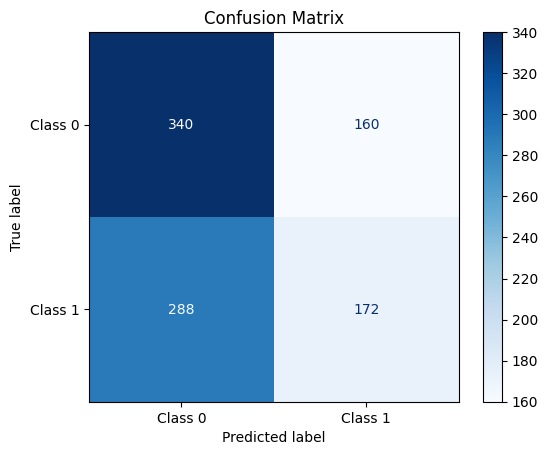

In [623]:

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues) # Use the plot() method
plt.title('Confusion Matrix')
plt.show()